<div align="center">
  <h1>Notebook 02: Statistical Hypothesis Testing & Biomarker Significance</h1>
  <h3>Biotech Project: Genomic Classification for Personalized Medicine</h3>
  <h3>Proyecto Biotecnológico: Clasificación Genómica para Medicina Personalizada</h3>
</div>

---

## 📌 Executive Summary / Resumen Ejecutivo

**[EN]** In precision medicine, observing a difference in genomic expression between healthy and pathological tissues is not enough; we must rigorously prove that these differences are statistically significant and not the result of random chance. However, conducting simultaneous statistical tests across multiple biological features inflates the probability of Type I errors (False Positives).

This notebook applies formal statistical inference to the orthogonal features (Principal Components) derived in Notebook 01. We will conduct independent two-sample $T$-tests to compare the mean expression profiles between clinical groups. Crucially, we will apply the Benjamini-Hochberg False Discovery Rate (FDR) correction to adjust our $p$-values, ensuring our clinical discoveries are mathematically sound before feeding them into the Machine Learning phase.

**[ES]** En la medicina de precisión, observar una diferencia en la expresión genómica entre tejidos sanos y patológicos no es suficiente; debemos demostrar rigurosamente que estas diferencias son estadísticamente significativas y no el resultado del azar. Sin embargo, realizar pruebas estadísticas simultáneas en múltiples características biológicas infla la probabilidad de errores de Tipo I (Falsos Positivos).

Este notebook aplica inferencia estadística formal a las características ortogonales (Componentes Principales) derivadas en el Notebook 01. Realizaremos pruebas $T$ de dos muestras independientes para comparar los perfiles de expresión media entre los grupos clínicos. Fundamentalmente, aplicaremos la corrección de Tasa de Falso Descubrimiento (FDR) de Benjamini-Hochberg para ajustar nuestros valores $p$, garantizando que nuestros descubrimientos clínicos sean matemáticamente sólidos antes de introducirlos en la fase de Machine Learning.

---

## 🎯 Hypotheses / Hipótesis

For each Principal Component (PC) / Para cada Componente Principal (PC):
*   **$H_0$ (Null Hypothesis / Hipótesis Nula):** $\mu_{pathological} = \mu_{healthy}$. There is no significant difference in the mean value of the principal component between pathological and healthy patients.
*   **$H_A$ (Alternative Hypothesis / Hipótesis Alternativa):** $\mu_{pathological} \neq \mu_{healthy}$. There is a statistically significant difference in the mean value between the two groups.
*   **Significance Level / Nivel de Significancia ($\alpha$):** 0.05

In [3]:
# ==============================================================================
# 1. Environment Configuration & Library Imports
# ==============================================================================
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical inference libraries
from scipy import stats
from statsmodels.stats.multitest import multipletests

# Configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)

# Path Management
PROJECT_ROOT = Path.cwd().parent
DIR_DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DIR_RESULTS_FIGS = PROJECT_ROOT / "results" / "figures"
DIR_RESULTS_DASH = PROJECT_ROOT / "results" / "dashboard_exports"

print(f"✅ Environment initialized for Statistical Inference.")

✅ Environment initialized for Statistical Inference.


### 2. Data Ingestion / Ingesta de Datos

**[EN]** We load the immutable, standardized, and dimensionally reduced dataset (`genomics_pca_cleaned.csv`) produced in Notebook 01.

**[ES]** Cargamos el conjunto de datos inmutable, estandarizado y reducido dimensionalmente (`genomics_pca_cleaned.csv`) producido en el Notebook 01.

In [6]:
# ==============================================================================
# 2. Load Processed Data
# ==============================================================================
def load_processed_data() -> pd.DataFrame:
    """Loads the PCA-transformed dataset."""
    input_path = DIR_DATA_PROCESSED / "genomics_pca_cleaned.csv"
    if not input_path.exists():
        raise FileNotFoundError(f"Processed dataset not found at {input_path}. Please run Notebook 01 first.")
    
    df = pd.read_csv(input_path)
    print(f"[+] Loaded processed dataset: {df.shape[0]} patients, {df.shape[1]-1} Principal Components.")
    return df

df_pca = load_processed_data()

[+] Loaded processed dataset: 569 patients, 10 Principal Components.


### 3. Hypothesis Testing & FDR Correction / Pruebas de Hipótesis y Corrección FDR

**[EN]** We iterate through each Principal Component and perform a Welch's $T$-test (which does not assume equal population variances). Subsequently, we apply the Benjamini-Hochberg (BH) procedure to control the False Discovery Rate (FDR). This adjustment is critical: an uncorrected $p$-value of 0.04 might be discarded after FDR correction due to the multiple comparisons problem.

**[ES]** Iteramos a través de cada Componente Principal y realizamos una prueba $T$ de Welch (que no asume varianzas poblacionales iguales). Posteriormente, aplicamos el procedimiento de Benjamini-Hochberg (BH) para controlar la Tasa de Falso Descubrimiento (FDR). Este ajuste es crítico: un valor $p$ no corregido de 0.04 podría descartarse tras la corrección FDR debido al problema de comparaciones múltiples.

In [9]:
# ==============================================================================
# 3. Statistical Testing Module
# ==============================================================================
def perform_hypothesis_testing(df: pd.DataFrame, alpha: float = 0.05) -> pd.DataFrame:
    """
    Executes Welch's T-tests across all feature columns comparing the two clinical groups.
    Applies Benjamini-Hochberg FDR correction to adjust p-values.
    """
    print("=" * 60)
    print("🔬 STATISTICAL HYPOTHESIS TESTING (WELCH'S T-TEST + FDR)")
    print("=" * 60)
    
    # Split cohorts
    pathological = df[df['target_pathology'] == 0].drop(columns=['target_pathology'])
    healthy = df[df['target_pathology'] == 1].drop(columns=['target_pathology'])
    
    features = pathological.columns
    test_results = []
    
    # Run independent T-tests
    for feature in features:
        # equal_var=False specifies Welch's T-test
        t_stat, p_val = stats.ttest_ind(pathological[feature], healthy[feature], equal_var=False)
        test_results.append({
            'Component': feature,
            'T_Statistic': t_stat,
            'P_Value_Raw': p_val,
            'Mean_Pathological': pathological[feature].mean(),
            'Mean_Healthy': healthy[feature].mean()
        })
        
    results_df = pd.DataFrame(test_results)
    
    # Apply Benjamini-Hochberg False Discovery Rate (FDR) correction
    print("[+] Applying Benjamini-Hochberg FDR correction...")
    reject, pvals_corrected, _, _ = multipletests(
        results_df['P_Value_Raw'], 
        alpha=alpha, 
        method='fdr_bh'
    )
    
    results_df['P_Value_FDR_Corrected'] = pvals_corrected
    results_df['Significant'] = reject
    
    # Sort by statistical significance
    results_df = results_df.sort_values(by='P_Value_FDR_Corrected').reset_index(drop=True)
    
    sig_count = results_df['Significant'].sum()
    print(f"[+] Total Components Analyzed: {len(features)}")
    print(f"[+] Components showing Statistically Significant differences: {sig_count}")
    print("=" * 60)
    
    return results_df

# Execute testing
df_stats = perform_hypothesis_testing(df_pca, alpha=0.05)

# Display the top 5 most significant components
display(df_stats.head())

🔬 STATISTICAL HYPOTHESIS TESTING (WELCH'S T-TEST + FDR)
[+] Applying Benjamini-Hochberg FDR correction...
[+] Total Components Analyzed: 10
[+] Components showing Statistically Significant differences: 5


,Component,T_Statistic,P_Value_Raw,Mean_Pathological,Mean_Healthy,P_Value_FDR_Corrected,Significant
0,PC_1,26.270063,3.235251e-78,3.714777,-2.205974,3.235251e-77,True
1,PC_2,-4.272858,2.476938e-05,-0.583135,0.346287,1.238469e-04,True
2,PC_3,-3.598840,3.699129e-04,-0.358956,0.213162,1.233043e-03,True
3,PC_4,-3.064367,2.314139e-03,-0.232972,0.138347,5.785347e-03,True
4,PC_5,-2.551695,1.099608e-02,-0.165439,0.098244,2.199215e-02,True


### 4. Results Visualization & Artifact Export / Visualización de Resultados y Exportación

**[EN]** We visualize the statistical significance using a $-\log_{10}(p\text{-value})$ transformation. Components crossing the threshold line ($\alpha = 0.05$ after FDR correction) represent reliable biological markers that differentiate the pathology. Finally, we export these statistical summaries to be used in the Dashboard phase.

**[ES]** Visualizamos la significancia estadística utilizando una transformación $-\log_{10}(p\text{-value})$. Los componentes que cruzan la línea de umbral ($\alpha = 0.05$ tras corrección FDR) representan marcadores biológicos confiables que diferencian la patología. Finalmente, exportamos estos resúmenes estadísticos para ser utilizados en la fase de Dashboard.

[+] Exported significance plot to: statistical_significance.png


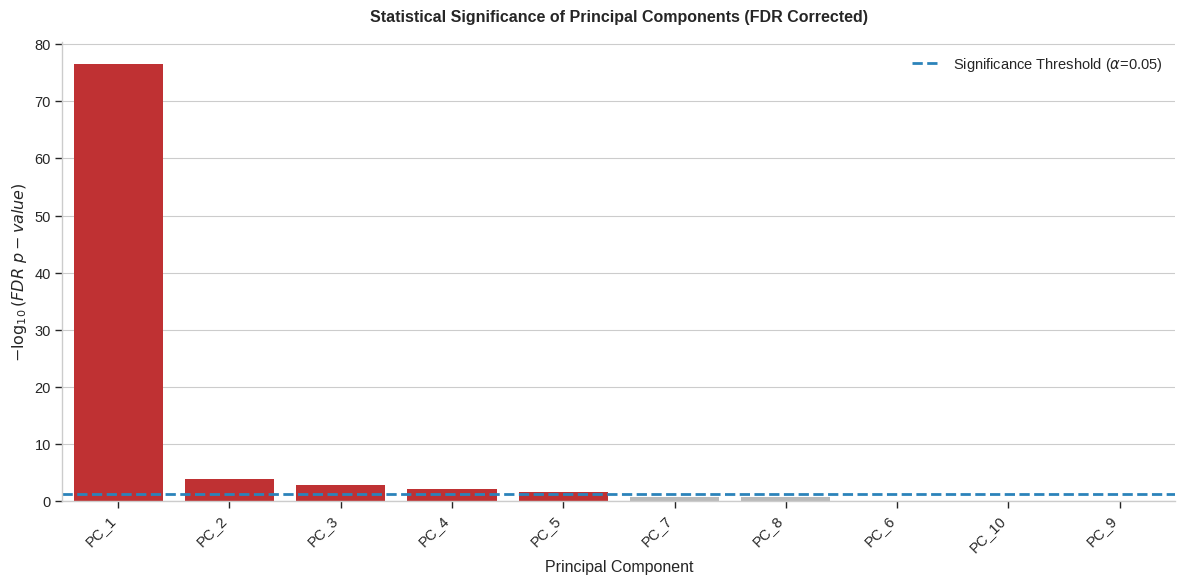

💾 SUCCESS: Statistical summary saved for Dashboard usage at: /home/pablosantana/portafolio/biotech-genomics-classifier/results/dashboard_exports/statistical_testing_summary.csv


In [14]:
# ==============================================================================
# 4. Visualization & Export Module
# ==============================================================================
def plot_statistical_significance(df_stats: pd.DataFrame, alpha: float = 0.05) -> None:
    """
    Plots the -log10(FDR p-values) to highlight statistically significant components.
    Similar to a Manhattan plot in genomic studies.
    """
    plt.figure(figsize=(12, 6))
    
    # Transform p-values for visualization
    df_stats['Neg_Log10_PVal'] = -np.log10(df_stats['P_Value_FDR_Corrected'])
    threshold = -np.log10(alpha)
    
    # Create color map based on significance
    colors = ['#d7191c' if sig else '#bababa' for sig in df_stats['Significant']]
    
    # Bar plot
    ax = sns.barplot(
        data=df_stats, 
        x='Component', 
        y='Neg_Log10_PVal', 
        palette=colors
    )
    
    # Threshold line
    plt.axhline(y=threshold, color='#2b83ba', linestyle='--', linewidth=2, 
                label=fr'Significance Threshold ($\alpha$={alpha})')
    
    plt.title('Statistical Significance of Principal Components (FDR Corrected)', weight='bold', pad=15)
    plt.xlabel('Principal Component')
    plt.ylabel('$-\log_{10}(FDR\ p-value)$')
    plt.xticks(rotation=45, ha='right')
    plt.legend()
    sns.despine()
    plt.tight_layout()
    
    # Save artifact
    output_path = DIR_RESULTS_FIGS / "statistical_significance.png"
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"[+] Exported significance plot to: {output_path.name}")
    plt.show()

def export_statistical_artifacts(df_stats: pd.DataFrame) -> None:
    """
    Exports the statistical summary to the dashboard exports directory.
    """
    output_path = DIR_RESULTS_DASH / "statistical_testing_summary.csv"
    df_stats.to_csv(output_path, index=False)
    print(f"💾 SUCCESS: Statistical summary saved for Dashboard usage at: {output_path}")

# Execute Visualization and Export
plot_statistical_significance(df_stats)
export_statistical_artifacts(df_stats)